# Nutrition Analysis

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import glob
import os

%matplotlib inline

pl.Config.set_fmt_str_lengths(200)
pl.Config.set_tbl_width_chars(2000)
pl.Config.set_tbl_rows(30)

polars.config.Config

## Data Loading

In [2]:
archive_dir = "../archive"
json_files = sorted(glob.glob(os.path.join(archive_dir, "*.json")))

In [3]:
dfs = []

target_schema = {
    "price": pl.Float64,
    "kcal": pl.Float64,
    "proteins": pl.Float64,
    "carbs": pl.Float64,
    "sugar": pl.Float64,
    "fat": pl.Float64,
    "saturated": pl.Float64,
    "salt": pl.Float64,
    "scoreCo2": pl.Int64,
    "scoreWater": pl.Int64,
    "scoreAnimals": pl.Int64,
    "scoreRainforest": pl.Int64,
    "co2Emissions": pl.Float64,
    "waterConsumption": pl.Float64,
    "name": pl.String,
    "line": pl.String,
    "type": pl.String,
    "additives": pl.List(pl.String)
}

expected_cols = [
    "name", "line", "price", "type", "kcal", "proteins", "carbs", "sugar", "fat", 
    "saturated", "salt", "additives", "scoreCo2", "scoreWater", "scoreAnimals", 
    "scoreRainforest", "co2Emissions", "waterConsumption"
]

for file in json_files:
    try:
        df = pl.read_json(file)
        
        if not df.is_empty() and df.width > 0:
            is_valid = True
            
            for col in df.columns:
                if col in target_schema:
                    current_dtype = df.schema[col]
                    target_dtype = target_schema[col]
                    
                    if current_dtype == target_dtype or current_dtype == pl.Null:
                         continue
                    if target_dtype in [pl.Float64, pl.Int64] and current_dtype in [pl.Float64, pl.Int64]:
                        continue
                    print(f"Skipping {file}: Invalid type for {col}: {current_dtype} (expected {target_dtype})")
                    is_valid = False
                    break
            
            if not is_valid:
                continue

            for col in expected_cols:
                target_dtype = target_schema.get(col, pl.String)
                if col not in df.columns:
                    df = df.with_columns(pl.lit(None, dtype=target_dtype).alias(col))
                else:
                    if df.schema[col] != target_dtype:
                         df = df.with_columns(pl.col(col).cast(target_dtype))
            
            df = df.select(expected_cols)
            dfs.append(df)
    except Exception as e:
        print(f"Error reading {file}: {e}")

if dfs:
    combined_df = pl.concat(dfs)
    combined_df = combined_df.unique(subset=["name"])
    
    nutrition_cols = ["kcal", "proteins", "carbs", "sugar", "fat", "saturated", "salt"]
    for col in nutrition_cols:
        combined_df = combined_df.filter(pl.col(col) > 0)
    
    env_cols = ["scoreCo2", "scoreWater", "scoreAnimals", "scoreRainforest"]
    for col in env_cols:
        if col in combined_df.columns:
             combined_df = combined_df.filter(pl.col(col) > 0)
             
    combined_df = combined_df.filter(pl.col("kcal") < 5000)
    
    print(f"Got shape: {combined_df.shape}")
else:
    print("No data loaded.")

Got shape: (1130, 18)


## Meal Type Distribution

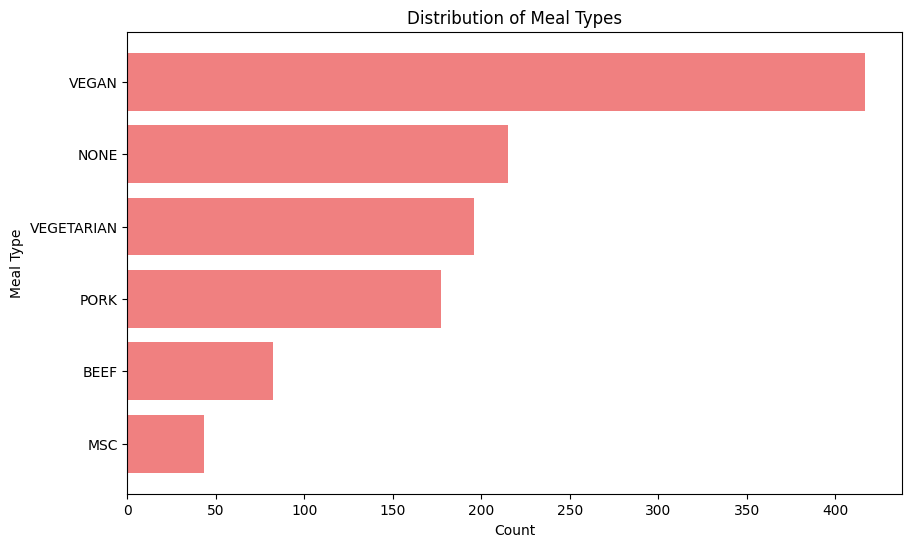

In [4]:
type_counts = combined_df["type"].value_counts().sort("count", descending=True)

plt.figure(figsize=(10, 6))
plt.barh(type_counts["type"], type_counts["count"], color='lightcoral')
plt.xlabel("Count")
plt.ylabel("Meal Type")
plt.title("Distribution of Meal Types")
plt.gca().invert_yaxis()
plt.show()

## CO2 Emissions Analysis

In [5]:
top_co2 = combined_df.filter(pl.col("co2Emissions").is_not_null()).sort("co2Emissions", descending=False).head(10).select(["name", "co2Emissions", "type", "line"])
print("Top 10 meals by CO2 Emissions:")
print(top_co2)

bottom_co2 = combined_df.filter(pl.col("co2Emissions") > 0).sort("co2Emissions", descending=True).head(10).select(["name", "co2Emissions", "type", "line"])
print("\nBottom 10 meals by CO2 Emissions:")
print(bottom_co2)


Top 10 meals by CO2 Emissions:
shape: (10, 4)
┌────────────────────────────────────┬──────────────┬────────────┬─────────┐
│ name                               ┆ co2Emissions ┆ type       ┆ line    │
│ ---                                ┆ ---          ┆ ---        ┆ ---     │
│ str                                ┆ f64          ┆ str        ┆ str     │
╞════════════════════════════════════╪══════════════╪════════════╪═════════╡
│ Tagessuppe Kartoffelsuppe          ┆ 40.0         ┆ VEGAN      ┆ LINIE_5 │
│ Kartoffelsuppe vegan               ┆ 48.0         ┆ VEGAN      ┆ LINIE_5 │
│ Vegane Kartoffelsuppe              ┆ 49.0         ┆ VEGAN      ┆ LINIE_5 │
│ Tagessuppe Flädlesuppe             ┆ 62.0         ┆ VEGETARIAN ┆ LINIE_5 │
│ Kartoffeln mit frischer Petersilie ┆ 70.0         ┆ VEGAN      ┆ LINIE_5 │
│ Risoleekartoffeln                  ┆ 70.0         ┆ VEGAN      ┆ LINIE_5 │
│ Ebly Weizen                        ┆ 71.0         ┆ VEGAN      ┆ LINIE_5 │
│ Vegane Karottensuppe        

## Protein Content Analysis

In [6]:
combined_df = combined_df.with_columns((pl.col("proteins") / pl.col("kcal")).alias("proteins_per_kcal"))

top_by_ratio = combined_df.sort("proteins_per_kcal", descending=True).head(25).select(["name", "proteins_per_kcal", "kcal", "proteins", "type", "line"])
print("\nTop 25 meals by proteins/kcal ratio:")
print(top_by_ratio)

bottom_by_ratio = combined_df.sort("proteins_per_kcal", descending=False).head(25).select(["name", "proteins_per_kcal", "kcal", "proteins", "type", "line"])
print("\nBottom 25 meals by proteins/kcal ratio:")
print(bottom_by_ratio)


Top 25 meals by proteins/kcal ratio:
shape: (25, 6)
┌────────────────────────────────────────────────────────────────────────────────────────┬───────────────────┬───────┬──────────┬────────────┬─────────┐
│ name                                                                                   ┆ proteins_per_kcal ┆ kcal  ┆ proteins ┆ type       ┆ line    │
│ ---                                                                                    ┆ ---               ┆ ---   ┆ ---      ┆ ---        ┆ ---     │
│ str                                                                                    ┆ f64               ┆ f64   ┆ f64      ┆ str        ┆ str     │
╞════════════════════════════════════════════════════════════════════════════════════════╪═══════════════════╪═══════╪══════════╪════════════╪═════════╡
│ Bunter Gemüse Wok mit Sojastreifen, Preis je 100g                                      ┆ 0.154882          ┆ 594.0 ┆ 92.0     ┆ VEGETARIAN ┆ LINIE_6 │
│ Reisnudel Wok mit PakChoi, 

## Kcal vs. Protein Correlation

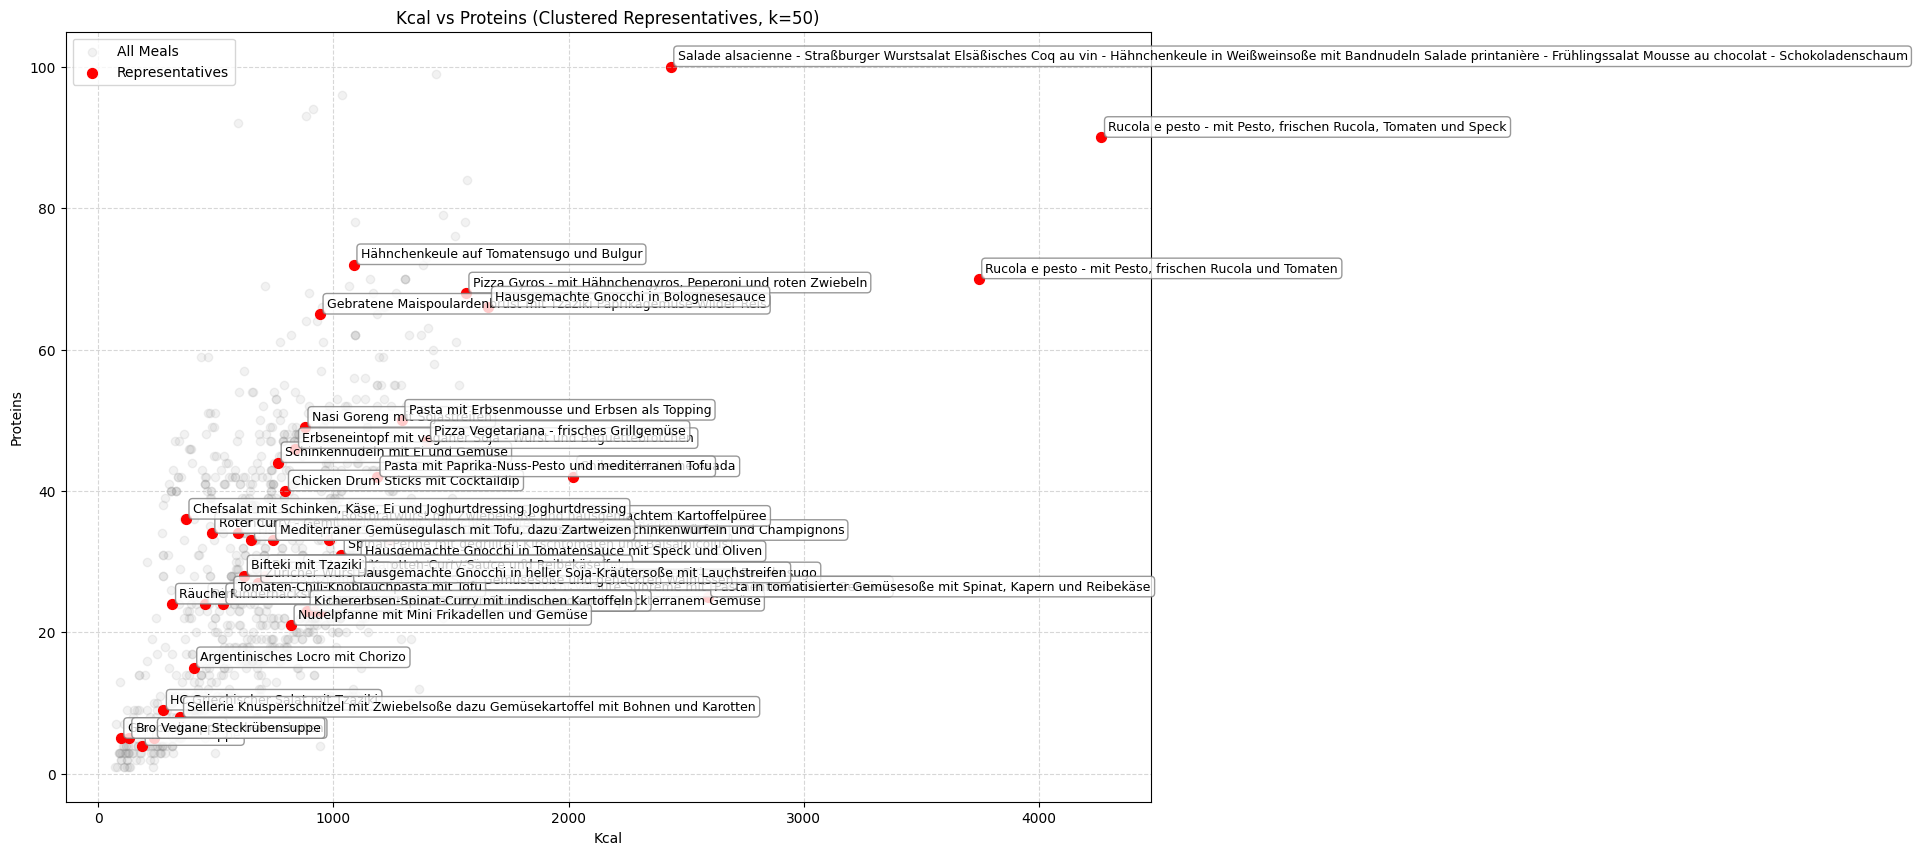

In [7]:
from sklearn.cluster import KMeans
import numpy as np

X = combined_df.select(["kcal", "proteins"]).to_numpy()

n_clusters = 50

if len(X) > n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans.fit(X)

    closest_indices = []
    for center in kmeans.cluster_centers_:
        distances = np.linalg.norm(X - center, axis=1)
        closest_idx = np.argmin(distances)
        closest_indices.append(closest_idx)

    representatives = combined_df[closest_indices]
else:
    representatives = combined_df

plt.figure(figsize=(14, 10))
plt.scatter(combined_df["kcal"], combined_df["proteins"], alpha=0.1, color='gray', label='All Meals')
plt.scatter(representatives["kcal"], representatives["proteins"], alpha=1.0, color='red', s=50, label='Representatives')

for name, kcal, protein in zip(representatives["name"], representatives["kcal"], representatives["proteins"]):
    plt.annotate(name, (kcal, protein), xytext=(5, 5), textcoords='offset points', fontsize=9, alpha=1.0, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

plt.xlabel("Kcal")
plt.ylabel("Proteins")
plt.title(f"Kcal vs Proteins (Clustered Representatives, k={n_clusters})")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

## Best proteins / kcal meals by type

In [8]:
best_by_type = combined_df.sort("proteins_per_kcal", descending=True).group_by("type").head(1)
best_by_type = best_by_type.select(["type", "name", "proteins_per_kcal", "kcal", "proteins"]).sort("proteins_per_kcal", descending=True)
print("Best protein/kcal meals by type:")
print(best_by_type)

Best protein/kcal meals by type:
shape: (6, 5)
┌────────────┬────────────────────────────────────────────────────────────────────────────────────────┬───────────────────┬───────┬──────────┐
│ type       ┆ name                                                                                   ┆ proteins_per_kcal ┆ kcal  ┆ proteins │
│ ---        ┆ ---                                                                                    ┆ ---               ┆ ---   ┆ ---      │
│ str        ┆ str                                                                                    ┆ f64               ┆ f64   ┆ f64      │
╞════════════╪════════════════════════════════════════════════════════════════════════════════════════╪═══════════════════╪═══════╪══════════╡
│ VEGETARIAN ┆ Bunter Gemüse Wok mit Sojastreifen, Preis je 100g                                      ┆ 0.154882          ┆ 594.0 ┆ 92.0     │
│ NONE       ┆ Reisnudel Wok mit PakChoi, Karotten, Sesam , Hähnchenstreifen und Ingwer-Ananas-